# B15 · Parameter-free encoders: limits and assumptions

**Skill:** identify what a predictor can know before comparing encoder parameters. Read [the lesson](https://avistian.github.io/relational/lessons/b15-parameter-free-encoders.html). This notebook is portable: Python standard library only; no downloads, repository imports or cloud calls. PROVIDED cells are complete; implement three TODO cells and run each CHECK. Submit the EXIT and written defense. Author execution is not learner mastery.

**Mirror scope:** finite illustrations of the information barriers discussed in Propositions 3.1/4.1 of [paper v2](https://arxiv.org/html/2607.05476v2). The general parity-graph proofs are not reproduced. Real-data Table 5 inference remains source-gated. Tier C synthetic data is appropriate here because the question is identifiability, not empirical model ranking.

## Concept recap

An encoder maps a local database view to features. A parameter-free encoder has no learned weights, but its head can be pretrained. Support labels are permitted examples; query labels are answers we must hide. Event time and label availability can differ.

If a neighbor has label b=0, both Copy (query 0) and Flip (query 1) remain possible. XOR returns 1 when its inputs differ, so y=b XOR theta names these two rules. An external example with input 1 and observed label 0 identifies Flip. Without it, equally likely rules give probability .5.

A second ambiguity concerns columns: (0,0)→0 and (1,1)→1 fit both y=A and y=B. Seeing labels does not identify a column when both explain them. A new labeled (0,1) row can distinguish them. These are existence examples, not claims about all tasks.

We enumerate all four rule worlds and eight column worlds, equally weighted, plus all 16 hidden-label interventions. Accuracy thresholds probability at .5; Brier is mean squared probability error. Mutual information measures reduction in uncertainty in bits: resolving two equally likely columns takes one bit.



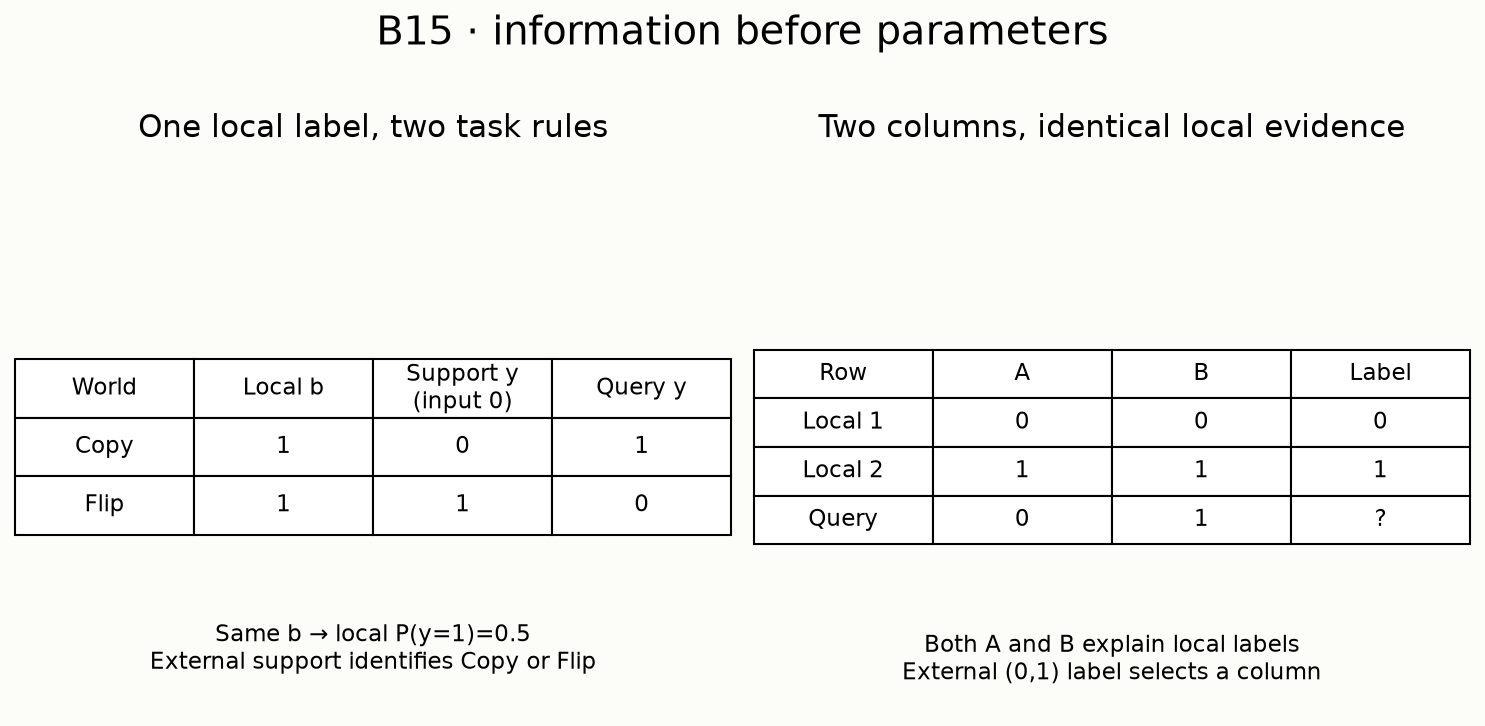

The first panel holds the local input fixed across worlds. The second holds local labeled examples fixed across possible relevant columns. External support changes the information boundary.

## PROVIDED · finite distribution and reporting

No optimization or pretrained models are hidden here. The full generator, information calculation and scoring are visible below; task functions are defined in your next cells.

In [ ]:
from collections import Counter
from itertools import product
import math

def mutual_information(pairs):
    """I(A;B) in bits for equally weighted finite observations (A,B)."""
    if not pairs:
        raise ValueError('Empty distribution')
    n=len(pairs);joint=Counter(pairs)
    ca=Counter(a for a,b in pairs);cb=Counter(b for a,b in pairs)
    return sum(c/n * math.log2(c*n/(ca[a]*cb[b])) for (a,b),c in joint.items())

def run_experiment():
    """Freeze all worlds, equal weights, no seeds, optimization or selection.

    Rule fixtures: a local neighboring label b is visible but its generating
    context is not. It does not tell us whether query y=b or y=1-b.
    External support (0,theta) reveals this relationship when permitted.
    Column fixtures: local labeled rows (0,0)->0, (1,1)->1 cannot identify S.
    External row (0,1)->S can identify S. Query truth stays outside legal inputs.
    """
    rules=[];columns=[];visibility=[]
    for theta,b in product((0,1),repeat=2):
        q=('query',10);remote=('remote',2);future=('future',3)
        records=[dict(key=q,available=10,label=b^theta),
                 dict(key=remote,available=4,label=theta),
                 dict(key=future,available=11,label=theta)]
        visible=visible_labels(records,q,10,{remote,future,q})
        support=[(0,y) for k,y in visible]
        rules.append(dict(theta=theta,b=b,truth=b^theta,
                          local=predict_rules(b,[]),expanded=predict_rules(b,support),
                          leaky=float(records[0]['label'])))
        # Intervene on both forbidden labels; legal support/predictions must agree.
        for qlabel,flabel in product((0,1),repeat=2):
            altered=[dict(r) for r in records]
            altered[0]['label']=qlabel;altered[2]['label']=flabel
            safe=visible_labels(altered,q,10,{remote,future,q})
            assert safe==visible
            visibility.append(dict(theta=theta,b=b,query_label=qlabel,future_label=flabel,
                                   safe=predict_rules(b,[(0,y) for k,y in safe]),
                                   leaked=float(qlabel)))
    local_support=[((0,0),0),((1,1),1)]
    for s,a,b in product((0,1),repeat=3):
        columns.append(dict(s=s,a=a,b=b,truth=(a,b)[s],
                            local=predict_columns((a,b),local_support),
                            expanded=predict_columns((a,b),local_support+[((0,1),s)])))
    def scores(rows,arm):
        return dict(accuracy=sum(int(r[arm]>=.5)==r['truth'] for r in rows)/len(rows),
                    brier=sum((r[arm]-r['truth'])**2 for r in rows)/len(rows))
    # Features and existing labels are identical under either S. The external
    # distinguishing label equals S. Repeating observations over queries keeps
    # S independent of query feature values under the enumerated uniform prior.
    info_local=mutual_information([(r['s'],(r['a'],r['b'],0,1)) for r in columns])
    info_expanded=mutual_information([(r['s'],(r['a'],r['b'],0,1,r['s'])) for r in columns])
    return dict(experiment='B15-LABEL-VISIBILITY',rules=rules,columns=columns,
                interventions=visibility,rule_scores={a:scores(rules,a) for a in ('local','expanded','leaky')},
                column_scores={a:scores(columns,a) for a in ('local','expanded')},
                information_bits=dict(local=info_local,expanded=info_expanded),
                scope='Exact finite illustrations; not general proofs or paper benchmark reproduction')

## TODO · visible_labels

Filter labels using declared context membership, full query identity, strict event cutoff and inclusive availability. Reject duplicate keys and invalid inputs. Goal: changing hidden truth must not change legal support. Hint: a row can be old but its label unavailable.

In [ ]:
def visible_labels(records, query_key, cutoff, allowed_keys):
    raise NotImplementedError("Complete visible_labels")

### CHECK · visible_labels

Run immediately. A correct implementation must pass before the next task.

In [ ]:
rows=[dict(key=('Q',10),available=9,label=1),dict(key=('A',2),available=4,label=0),dict(key=('B',3),available=11,label=1)]
assert visible_labels(rows,('Q',10),10,{r['key'] for r in rows})==[(('A',2),0)]
rows[0]['label']=0;rows[2]['label']=0
assert visible_labels(rows,('Q',10),10,{r['key'] for r in rows})==[(('A',2),0)]
print('Visibility CHECK passed')

## TODO · predict_rules

Retain every binary Copy/Flip rule consistent with the permitted support pairs; average their query predictions. Reject inconsistent support. Goal: expose uncertainty instead of guessing the world. Hint: the world is not an input to this function.

In [ ]:
def predict_rules(query_bit, support):
    raise NotImplementedError("Complete predict_rules")

### CHECK · predict_rules

Run immediately. A correct implementation must pass before the next task.

In [ ]:
assert predict_rules(1,[]) == .5
assert predict_rules(1,[(0,1)]) == 0
assert predict_rules(0,[(1,1)]) == 0
try: predict_rules(0,[(0,0),(0,1)])
except ValueError: pass
else: raise AssertionError('Contradictory support accepted')
print('Rule CHECK passed')

## TODO · predict_columns

Retain each of the two columns that matches all permitted labeled examples; average its query values. Reject inconsistent support. Goal: distinguish predictive agreement from identifying the relevant feature. Hint: do not choose a column simply because both fit.

In [ ]:
def predict_columns(query, support):
    raise NotImplementedError("Complete predict_columns")

### CHECK · predict_columns

Run immediately. A correct implementation must pass before the next task.

In [ ]:
assert predict_columns((1,0),[((0,0),0),((1,1),1)]) == .5
assert predict_columns((1,0),[((0,1),0)]) == 1
assert predict_columns((0,0),[]) == 0
print('Column CHECK passed')

## Complete finite run and independent expected values

The full distribution is enumerated. Local column accuracy exceeds chance when A=B, even though S stays unidentified. Explain this before running.

In [ ]:
import json
report=run_experiment()
assert report['rule_scores']['local']=={'accuracy':.5,'brier':.25}
assert report['column_scores']['local']=={'accuracy':.75,'brier':.125}
assert report['information_bits']=={'local':0.0,'expanded':1.0}
assert len(report['interventions'])==16
from pathlib import Path
Path('b15-diagnostic.json').write_text(json.dumps(report,indent=2)+'\n')
print(json.dumps({k:v for k,v in report.items() if k.endswith('scores') or k=='information_bits'},indent=2))

## EXIT · separate evidence from mastery

Write 150 words explaining the existence quantifier, the information-access change, why perfect leakage fails, and why a parameter-free encoder may have a trained head. Return after 1/7/30 days. Ask the teacher about any unclear proof or code step.

In [ ]:
print('B15-LABEL-VISIBILITY: COMPLETE_FINITE_DIAGNOSTIC')
print('Paper inference: NOT_RUN; full suite and pretraining: NOT_RUN')
print('Learner: PENDING_WRITTEN_DEFENSE')

## NEXT STEP · selected Table 5 source audit

**Selected paper status: `INCOMPLETE_SOURCE_PROTOCOL_GATE`.** No fresh paper inference ran; cloud spend is **$0**. Exact candidate/seed/checkpoint/refit mapping remains unavailable in the pinned release. A runnable generic example is not an authenticated experiment receipt.

The complete pinned upstream source and paper are embedded below, together with a hash-checking operator. Running this archive extraction is local and free. The guarded paper attempt authenticates sources then refuses an undefined benchmark; it does not launch cloud work. Source commit 78561f0 has history OFF in code, ON in README. Inspect both and distinguish defaults from run receipts. Required missing details: full candidate grid, seeds/subsamples, checkpoint identities, validation/refit/snapshot mapping and data/environment provenance. The generic F1 example cannot substitute for the trial task. Budget USD10 aggregate, stop USD8/reserve USD2, local 3600 seconds; current cloud USD0.

In [ ]:
import base64, io, zipfile, subprocess, sys
from pathlib import Path
packet=Path('b15-source-packet'); packet.mkdir(exist_ok=True)
archive=zipfile.ZipFile(io.BytesIO(base64.b64decode('...')))
archive.extractall(packet)
result=subprocess.run([sys.executable,str(packet/'_reproduce_b15.py'),'--phase','audit'],capture_output=True,text=True,check=True)
print(result.stdout)

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    subprocess.run([sys.executable,str(packet/'_reproduce_b15.py'),'--phase','paper'],check=True)
else:
    print('Paper run remains OFF; original Table 5 configuration must be recovered first.')